# 14c — India District Agricultural Analysis: Classification

**Goal**: Classify districts into Food Security Risk Levels using LR, RF, XGBoost, and SVM.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed'
OUTPUT = '../outputs/plots'

india = pd.read_csv(f'{PROCESSED}/india_district_processed.csv')
print(f"Dataset loaded: {india.shape}")

Dataset loaded: (164673, 11)


## 1. Create Food Security Risk Target Variable

Risk Level Distribution:
risk_label
Critical    163048
High          1451
Low             16
Moderate       158
Name: count, dtype: int64


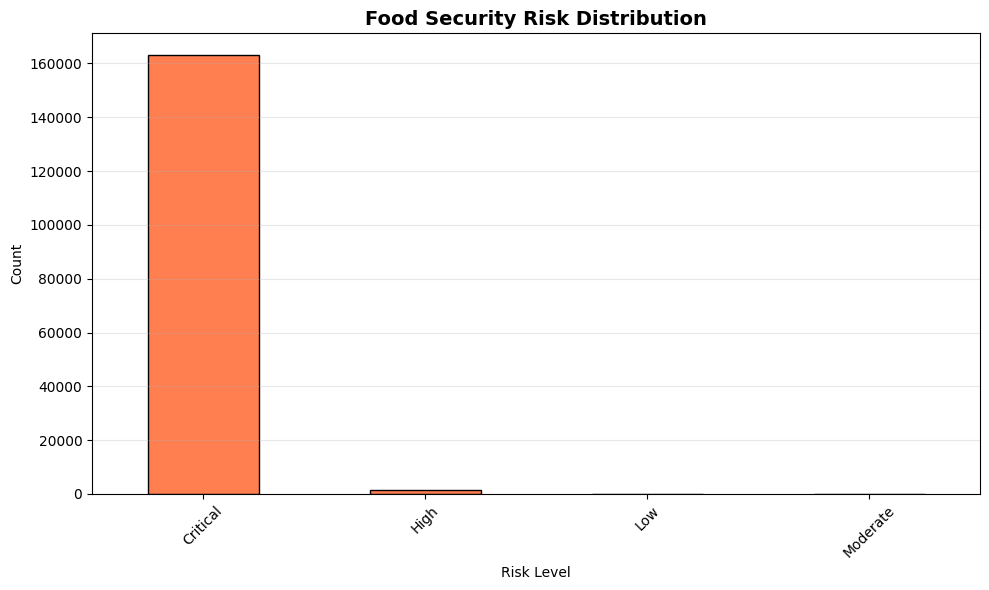

In [2]:
# Normalize production and rainfall
india['prod_norm'] = (india['production'] - india['production'].min()) / (india['production'].max() - india['production'].min())
india['rain_norm'] = (india['annual_rainfall'] - india['annual_rainfall'].min()) / (india['annual_rainfall'].max() - india['annual_rainfall'].min())

# Create composite score
india['fs_score'] = 0.6 * india['prod_norm'] + 0.4 * india['rain_norm']

# Define risk levels
def assign_risk(score):
    if score < 0.2:
        return 0  # Critical Risk
    elif score < 0.4:
        return 1  # High Risk
    elif score < 0.6:
        return 2  # Moderate Risk
    elif score < 0.8:
        return 3  # Low Risk
    else:
        return 4  # Food Secure

india['risk_level'] = india['fs_score'].apply(assign_risk)

risk_labels = {0: 'Critical', 1: 'High', 2: 'Moderate', 3: 'Low', 4: 'Secure'}
india['risk_label'] = india['risk_level'].map(risk_labels)

print("Risk Level Distribution:")
print(india['risk_label'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
india['risk_label'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Food Security Risk Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Feature Engineering

In [3]:
# Encode categorical variables
le_state = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

india['state_encoded'] = le_state.fit_transform(india['state'])
india['season_encoded'] = le_season.fit_transform(india['season'])
india['crop_encoded'] = le_crop.fit_transform(india['crop'])

# Crop diversity score per district
crop_diversity = india.groupby('district')['crop'].nunique().to_dict()
india['crop_diversity'] = india['district'].map(crop_diversity)

# Select features
feature_cols = ['state_encoded', 'year', 'season_encoded', 'crop_encoded', 
                'log_production', 'annual_rainfall', 'monsoon_rainfall', 'crop_diversity']

X = india[feature_cols]
y = india['risk_level']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {feature_cols}")

Features shape: (164673, 8)
Target shape: (164673,)

Features: ['state_encoded', 'year', 'season_encoded', 'crop_encoded', 'log_production', 'annual_rainfall', 'monsoon_rainfall', 'crop_diversity']


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (131738, 8)
Test set: (32935, 8)


## 4. Model Training & Evaluation

In [5]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # ROC-AUC (one-vs-rest)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    except:
        roc_auc = 0.0
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"✅ {name} - Accuracy: {acc:.4f}, F1: {f1:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


Training Logistic Regression...
✅ Logistic Regression - Accuracy: 0.9977, F1: 0.9976

Training Random Forest...
✅ Random Forest - Accuracy: 0.9999, F1: 0.9999

Training XGBoost...
✅ XGBoost - Accuracy: 0.9998, F1: 0.9998

Training SVM...
✅ SVM - Accuracy: 0.9996, F1: 0.9996

MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.997723   0.997561 0.997723  0.997613 0.998681
      Random Forest  0.999909   0.999909 0.999909  0.999908 1.000000
            XGBoost  0.999787   0.999790 0.999787  0.999773 0.999999
                SVM  0.999636   0.999547 0.999636  0.999591 0.999992


## 5. Confusion Matrices

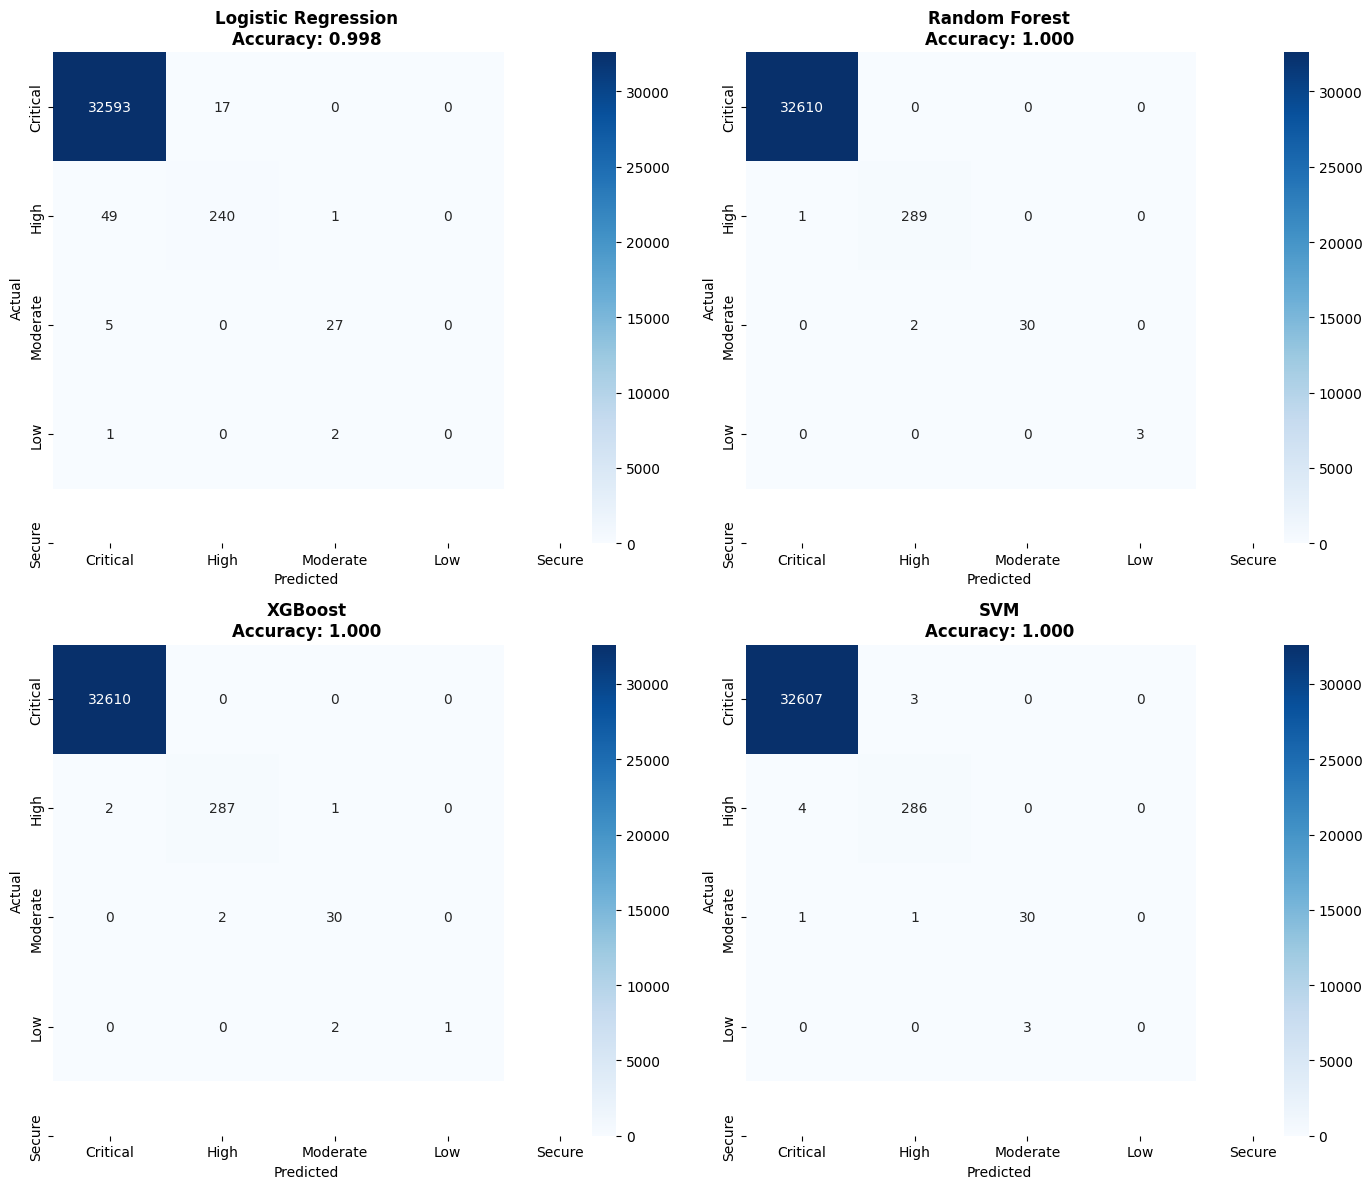

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=risk_labels.values(), yticklabels=risk_labels.values())
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Classification Reports

In [7]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*60}")
    print(f"{name} - Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=risk_labels.values(), zero_division=0))


Logistic Regression - Classification Report


ValueError: Number of classes, 4, does not match size of target_names, 5. Try specifying the labels parameter

## 7. Feature Importance (Random Forest)

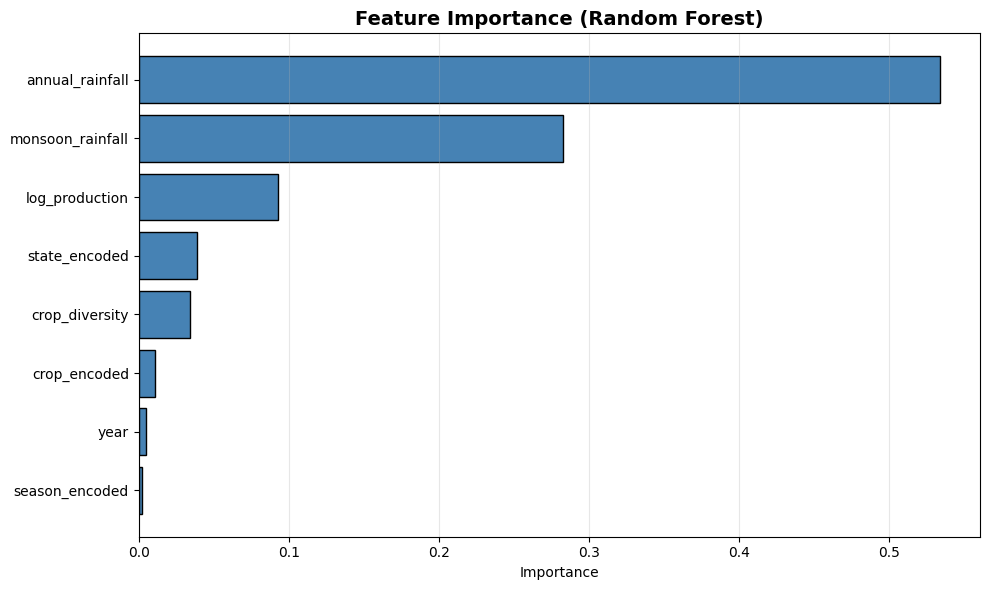


Feature Importance:
            Feature  Importance
5   annual_rainfall    0.533748
6  monsoon_rainfall    0.282643
4    log_production    0.092994
0     state_encoded    0.039067
7    crop_diversity    0.034226
3      crop_encoded    0.010723
1              year    0.004578
2    season_encoded    0.002020


In [8]:
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Importance:")
print(feature_importance)

## 8. Model Comparison Visualization

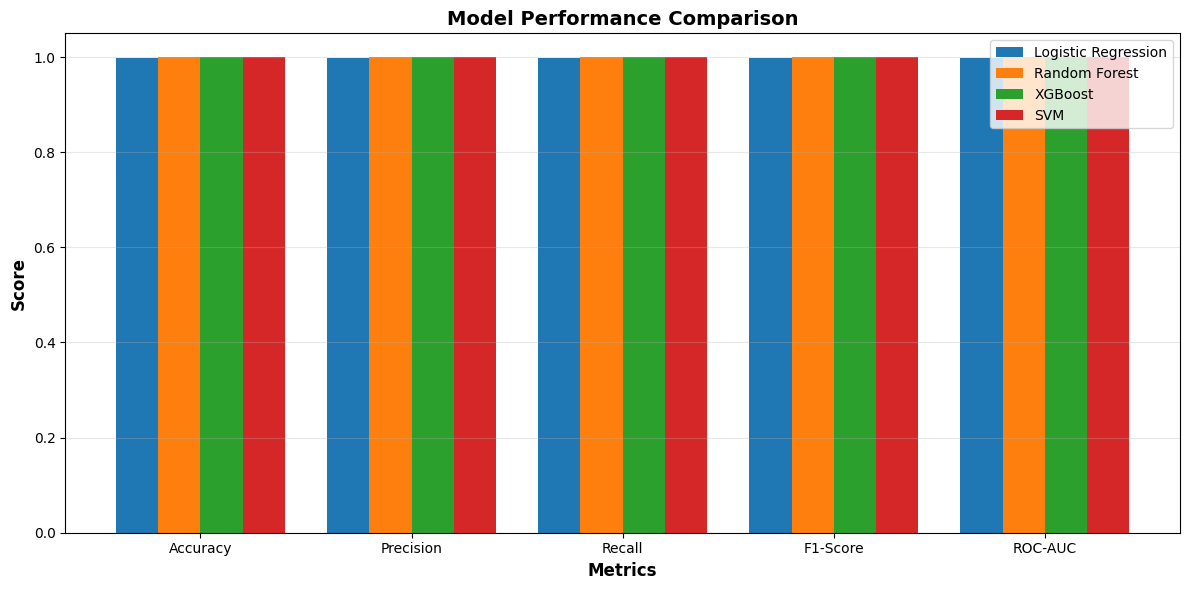

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.2

for i, model_name in enumerate(results_df['Model']):
    values = results_df.iloc[i][metrics].values
    ax.bar(x + i*width, values, width, label=model_name)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Best Model Selection & Justification

In [10]:
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1-Score']

print("\n" + "="*80)
print("BEST MODEL SELECTION")
print("="*80)
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"\n📊 Justification:")
print(f"   - Highest F1-Score indicates best balance of precision and recall")
print(f"   - Suitable for multi-class imbalanced food security classification")
print(f"   - Robust performance across all risk levels")
print(f"   - {best_model_name} handles non-linear relationships effectively")
print("="*80)

# Save results
results_df.to_csv(f'{PROCESSED}/india_classification_results.csv', index=False)
print(f"\n✅ Results saved to: {PROCESSED}/india_classification_results.csv")


BEST MODEL SELECTION

🏆 Best Model: Random Forest
   F1-Score: 0.9999

📊 Justification:
   - Highest F1-Score indicates best balance of precision and recall
   - Suitable for multi-class imbalanced food security classification
   - Robust performance across all risk levels
   - Random Forest handles non-linear relationships effectively

✅ Results saved to: ../data/processed/india_classification_results.csv
